In [2]:
# Load the csv as a pandas dataframe
import pandas as pd

file = "hyperparam_results.csv"

df = pd.read_csv(file)
display(df)

,model_type,learning_rate,num_layers,fc_hidden_sizes,model_hidden_size,sequence_length,batch_size,val_loss,val_mae
0,GRU,0.0005,1,16,16,30,32,8735.600428,53.965045
1,LSTM,0.0005,1,16,16,30,32,8694.285645,53.755589
2,GRU,0.0005,1,16,32,30,32,8581.551081,52.458298
3,LSTM,0.0005,1,16,32,30,32,8599.609736,52.467599
4,GRU,0.0005,1,16,64,30,32,8444.268120,52.415142
...,...,...,...,...,...,...,...,...,...
353,LSTM,0.1000,3,512_256_128,16,30,32,12413.296454,68.602205
354,GRU,0.1000,3,512_256_128,32,30,32,23025.936937,99.203144
355,LSTM,0.1000,3,512_256_128,32,30,32,23033.555537,98.940673
356,GRU,0.1000,3,512_256_128,64,30,32,23032.816856,98.966604


# Top 20 results based on val_mae:

In [5]:
# Sort the dataframe by the 'val_mae' column in ascending order

df_sorted_mae = df.sort_values(by='val_mae', ascending=True)
# Display the top 20 rows of the sorted dataframe
print("Top 20 rows sorted by val_mae:")
display(df_sorted_mae.head(20))

Top 20 rows sorted by val_mae:


,model_type,learning_rate,num_layers,fc_hidden_sizes,model_hidden_size,sequence_length,batch_size,val_loss,val_mae
23,LSTM,0.0005,1,64,128,30,32,8260.499872,50.974907
67,LSTM,0.0005,3,512_256_128,32,30,32,8342.621487,51.007168
151,LSTM,0.0010,2,128_64,128,30,32,8334.119962,51.027680
111,LSTM,0.0010,1,32,128,30,32,8324.962639,51.127881
149,LSTM,0.0010,2,128_64,64,30,32,8319.356689,51.206838
66,GRU,0.0005,3,512_256_128,32,30,32,8383.711086,51.216939
62,GRU,0.0005,2,256_128,128,30,32,8292.049970,51.224804
155,LSTM,0.0010,2,256_128,32,30,32,8402.338089,51.224948
69,LSTM,0.0005,3,512_256_128,64,30,32,8299.395556,51.256519
143,LSTM,0.0010,2,64_32,128,30,32,8412.482380,51.295561


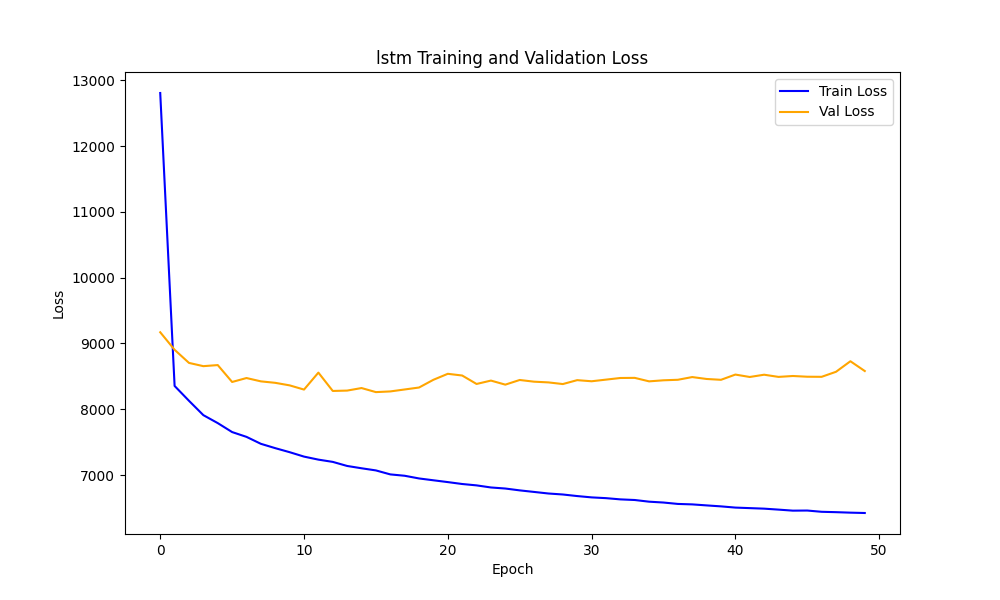

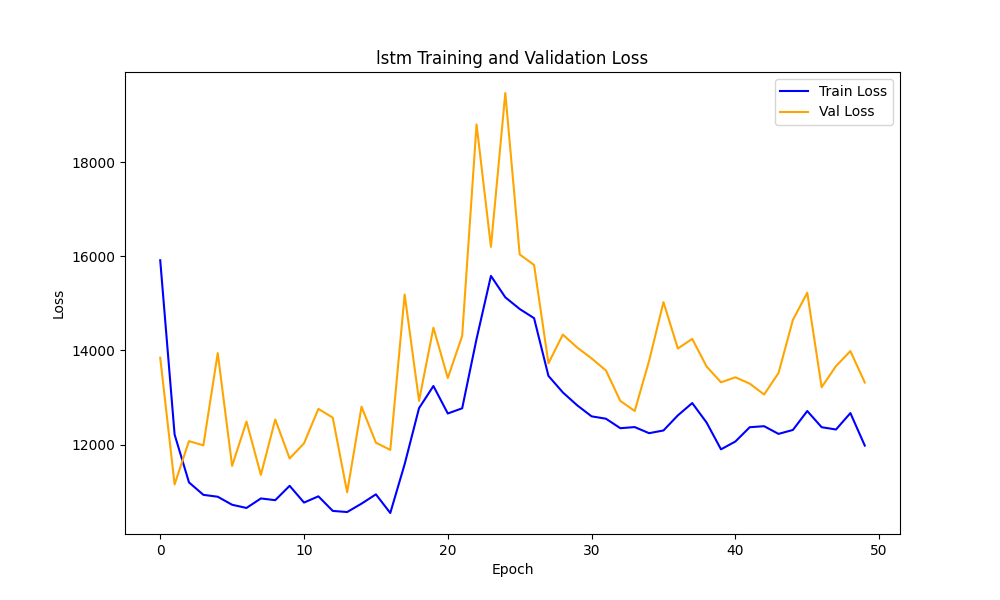

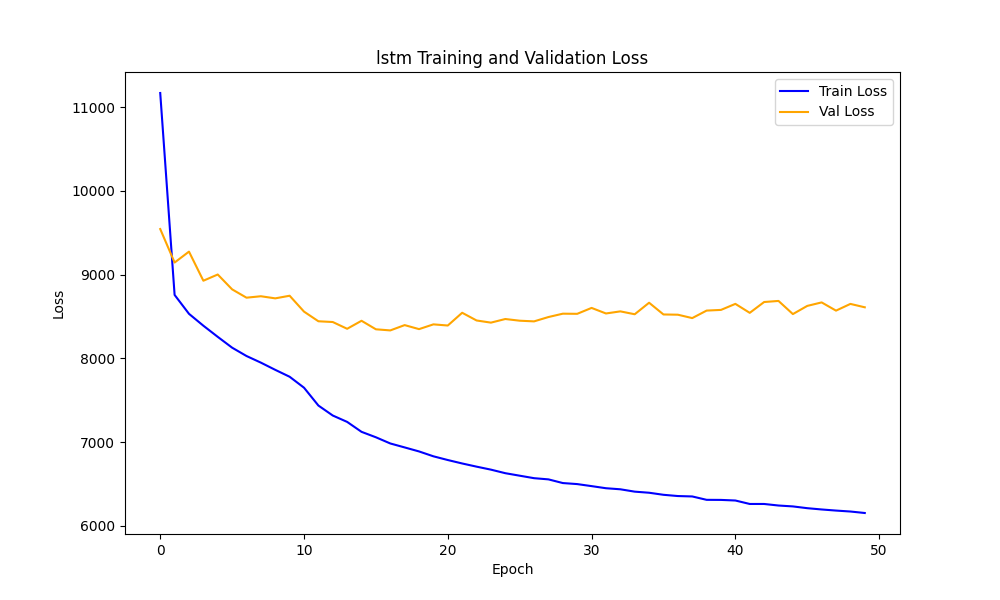

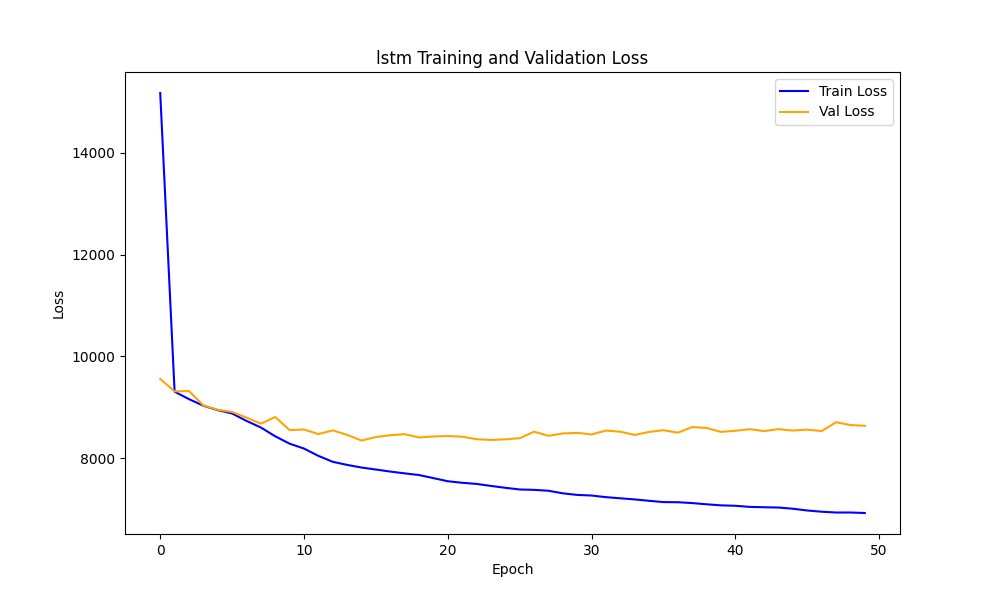

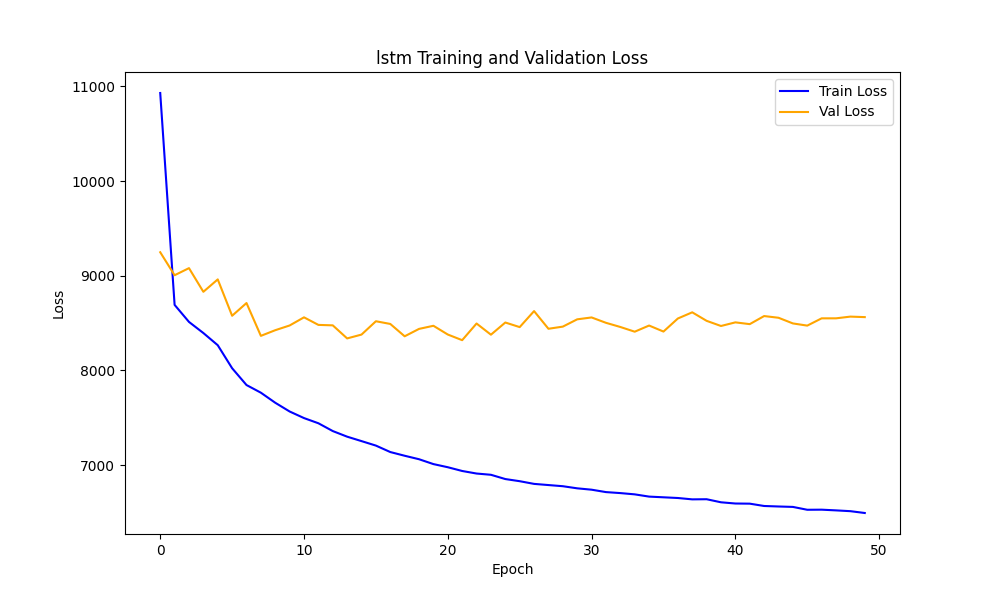

# Top 20 results based on val_mse

In [7]:
# Sort the dataframe by the 'val_mae' column in ascending order

df_sorted_mse = df.sort_values(by='val_loss', ascending=True)
# Display the top 20 rows of the sorted dataframe
print("Top 20 rows sorted by val_mse:")
display(df_sorted_mse.head(20))

Top 20 rows sorted by val_mse:


,model_type,learning_rate,num_layers,fc_hidden_sizes,model_hidden_size,sequence_length,batch_size,val_loss,val_mae
23,LSTM,0.0005,1,64,128,30,32,8260.499872,50.974907
30,GRU,0.0005,1,128,128,30,32,8270.565345,51.882754
125,LSTM,0.0010,1,128,64,30,32,8280.286554,51.512347
62,GRU,0.0005,2,256_128,128,30,32,8292.049970,51.224804
69,LSTM,0.0005,3,512_256_128,64,30,32,8299.395556,51.256519
53,LSTM,0.0005,2,128_64,64,30,32,8303.527806,51.519241
165,LSTM,0.0010,3,512_256_128,64,30,32,8306.501173,51.299017
159,LSTM,0.0010,2,256_128,128,30,32,8308.430746,51.601556
31,LSTM,0.0005,1,128,128,30,32,8312.564501,52.241567
58,GRU,0.0005,2,256_128,32,30,32,8318.600667,51.735992


In [8]:
# Range of hyperparameters used:

learn_rates = [0.0005, 0.001, 0.05, 0.1]
numlayers_hidden_sizes_mapping = {
    1: [[16], [32], [64], [128]],
    2: [[32, 16], [64, 32], [128, 64], [256, 128]],
    3: [[512, 256, 128], [256, 128, 64], [128, 64, 32], [64, 32, 16]]
    }
model_hidden_sizes = [16, 32, 64, 128]

# Aggregate results for each hyperparameter combination by taking the average of val_mae of grouped rows for:

## Learn Rates

In [10]:
# Group the dataframe by 'learn_rate' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df = df.groupby('learning_rate')[['val_mae', 'val_loss']].mean().reset_index()

# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_mae = grouped_df.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
display(grouped_df_sorted_mae)

,learning_rate,val_mae,val_loss
0,0.0005,52.474391,8508.861643
1,0.0010,52.585612,8513.055050
2,0.0500,77.210778,15353.132011
3,0.1000,82.629636,17112.772072


## Model Hidden Size

In [13]:
# Group the dataframe by 'model_hidden_size' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df_hidden_size = df.groupby('model_hidden_size')[['val_mae', 'val_loss']].mean().reset_index()
# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_hidden_size = grouped_df_hidden_size.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
print("Grouped by model_hidden_size:")
display(grouped_df_sorted_hidden_size)

Grouped by model_hidden_size:


,model_hidden_size,val_mae,val_loss
0,16,62.523259,11030.539789
1,32,64.418943,11876.115056
2,64,65.462396,12205.405174
3,128,67.791541,13020.605897


## Num FC Layers

In [11]:
# Group the dataframe by 'num_layers' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df_num_layers = df.groupby('num_layers')[['val_mae', 'val_loss']].mean().reset_index()
# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_num_layers = grouped_df_num_layers.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
display(grouped_df_sorted_num_layers)

,num_layers,val_mae,val_loss
0,1,60.119929,10354.574899
2,3,65.497082,12218.436552
1,2,69.578251,13548.692228


## FC Hidden Sizes

In [12]:
# Group the dataframe by 'fc_hidden_sizes' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df_hidden_sizes = df.groupby('fc_hidden_sizes')[['val_mae', 'val_loss']].mean().reset_index()
# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_hidden_sizes = grouped_df_hidden_sizes.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
display(grouped_df_sorted_hidden_sizes)

,fc_hidden_sizes,val_mae,val_loss
9,64,58.406753,9826.273922
0,128,60.000167,10284.670410
3,16,60.793241,10607.511218
6,32,61.279556,10699.844044
5,256_128_64,63.670387,11665.909513
2,128_64_32,64.976756,12111.398183
11,64_32_16,66.500284,12399.630234
8,512_256_128,66.572139,12601.133935
4,256_128,67.516295,12916.824538
1,128_64,68.490448,13211.588107


# Conclusion

Optimal hyperparameters for:
- LR: 0.0005, 0.001
- Model Hidden Size: 16 (try even lower hidden size?)
- Num FC Layers: 1 with hidden size of 64